# Visualisation of embeddings' distributions

## Requirements

In [10]:
import os
import sys
import json
from typing import Dict
from pathlib import Path
sys.path.insert(0, os.path.join("..", "..", "src"))

import deeplake
import numpy as np
import pandas as pd
import seaborn as sns
from umap import UMAP
from tqdm import tqdm
import plotly.express as px
import matplotlib.pyplot as plt



# ==================
#   PATH CONSTANTS
# ==================
import os
from pathlib import Path
ROOT_DIR = "/home/leolr-int/nfs/AGGCPerturbations"
#ROOT_DIR = str(Path(__file__).resolve().parents[2])
SRC_DIR = os.path.join(ROOT_DIR, "src")
ASSET_DIR = os.path.join(ROOT_DIR, "assets")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")
PROFILING_DIR = os.path.join(ROOT_DIR, "profiling")
#DATA_DIR = os.path.join(ROOT_DIR, "data")
#DATA_DIR = '/home/leolr-int/nfs/data/data'
DATA_DIR = '/home/leolr-int/nfs/transformed_data/FDA_CD_deeplake'
RAW_DIR = os.path.join(DATA_DIR, "raw")
RUN_DIR = os.path.join(ROOT_DIR, "tensorboard")
SPLIT_DIR = os.path.join(DATA_DIR, "splits")
CONFIG_DIR = os.path.join(ROOT_DIR, "configs")
PATCH_DIR = os.path.join(DATA_DIR, "patched")
#METADATA_DIR = os.path.join(DATA_DIR, "metadata")
METADATA_DIR = '/home/leolr-int/nfs/data/data/metadata'
#EMBEDDING_DIR = os.path.join(ROOT_DIR, "embeddings")
EMBEDDING_DIR = '/home/leolr-int/nfs/transformed_data/new_embeddings'

PATCH_TABLE_DIR = os.path.join(DATA_DIR, "patch_tables")
BASE_MODEL_DIR = os.path.join(ROOT_DIR, "model_weights")
FULL_PATCH_DIR = os.path.join(DATA_DIR, "patched_full") # only used for downstream analysis
HISTOGRAM_DIR = os.path.join(DATA_DIR, "histogram_matching_stats")
COMBINED_PATCH_DIR = os.path.join(DATA_DIR, "patched_combined")

LABEL_MAP = {
    "Stroma": 0,
    "Normal": 1,
    "G3":     2,
    "G4":     3,
    "G5":     4
}

COLOR_MAP = {
    0: [242, 182, 216],   
    1: [163, 196, 243],  
    2: [255, 213, 128],   
    3: [190, 224, 200],   
    4: [217, 185, 255],   
}

SEVERITY_COLOR_MAP = {
    0: [255, 0,     255],
    1: [51,  0,     255],
    2: [51,  255,   0  ],
    3: [255, 229.5, 0  ],
    4: [255, 0,     0  ]
}



## Visualisation


In [11]:
def subsample(ds, sample_percantage: float, scanner_name: str, label_map: dict) -> pd.DataFrame:
    if not (0 <= sample_percantage <= 1):
        raise ValueError("sample_percantage must be between 0 and 1")

    unique_labels = np.unique(ds["label"][:]).tolist()
    embeddings, labels, scanners = [], [], []

    for label in tqdm(unique_labels, desc=f"Subsampling {scanner_name}"):
        filtered = ds.query(f"SELECT * WHERE label == {label}")
        indices = np.random.choice(
            len(filtered),
            size=int(len(filtered) * sample_percantage),
            replace=False
        )

        sampled = filtered[*indices]
        embeddings.extend(sampled["embedding"])
        labels.extend(sampled["label"])
        scanners.extend([scanner_name] * len(indices))

    df = pd.DataFrame({
        "embedding": embeddings,
        "label": labels,
        "scanner": scanners
    })

    df["label"] = df["label"].map(label_map)
    return df

In [12]:
scanners = ['Akoya', 'KFBio', 'FDA_CD']
ds_paths = [os.path.join(EMBEDDING_DIR, ds_path, "mixed_precision/dim_256/Train/gigapath") for ds_path in scanners]


id_to_class = {v: k for k, v in LABEL_MAP.items()}
sample_percentage = 0.4  # modify maybe??

dfs = []
for scanner, path in zip(scanners, ds_paths):
    ds = deeplake.open_read_only(path)
    df = subsample(ds, sample_percentage, scanner, id_to_class)
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

Subsampling FDA_CD: 100%|██████████| 5/5 [00:28<00:00,  5.65s/it]


In [13]:
df_all.head()

,embedding,label,scanner
0,"[-0.3399952, -1.7461845, 1.1005175, -0.2001217...",Stroma,Akoya
1,"[-0.23624037, -1.5715619, 0.017552737, -0.1077...",Stroma,Akoya
2,"[-0.24097149, -1.6514976, -1.1396242, 0.365135...",Stroma,Akoya
3,"[-0.9931055, -1.7774386, 1.4770169, 0.28301907...",Stroma,Akoya
4,"[0.016050572, -0.4903467, 0.9236885, 0.5682862...",Stroma,Akoya


In [14]:
X = np.stack(df_all["embedding"].values)
umap_proj = UMAP(n_components=2, random_state=42).fit_transform(X)
df_all["umap_x"] = umap_proj[:, 0]
df_all["umap_y"] = umap_proj[:, 1]


unique_labels = sorted(df_all["label"].unique())
n_labels = 5



/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/leolr-int/micromamba/envs/py312-poetry/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/tmp/ipykernel_496433/1468620164.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/1468620164.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/1468620164.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/1468620164.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/1468620164.py:7: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


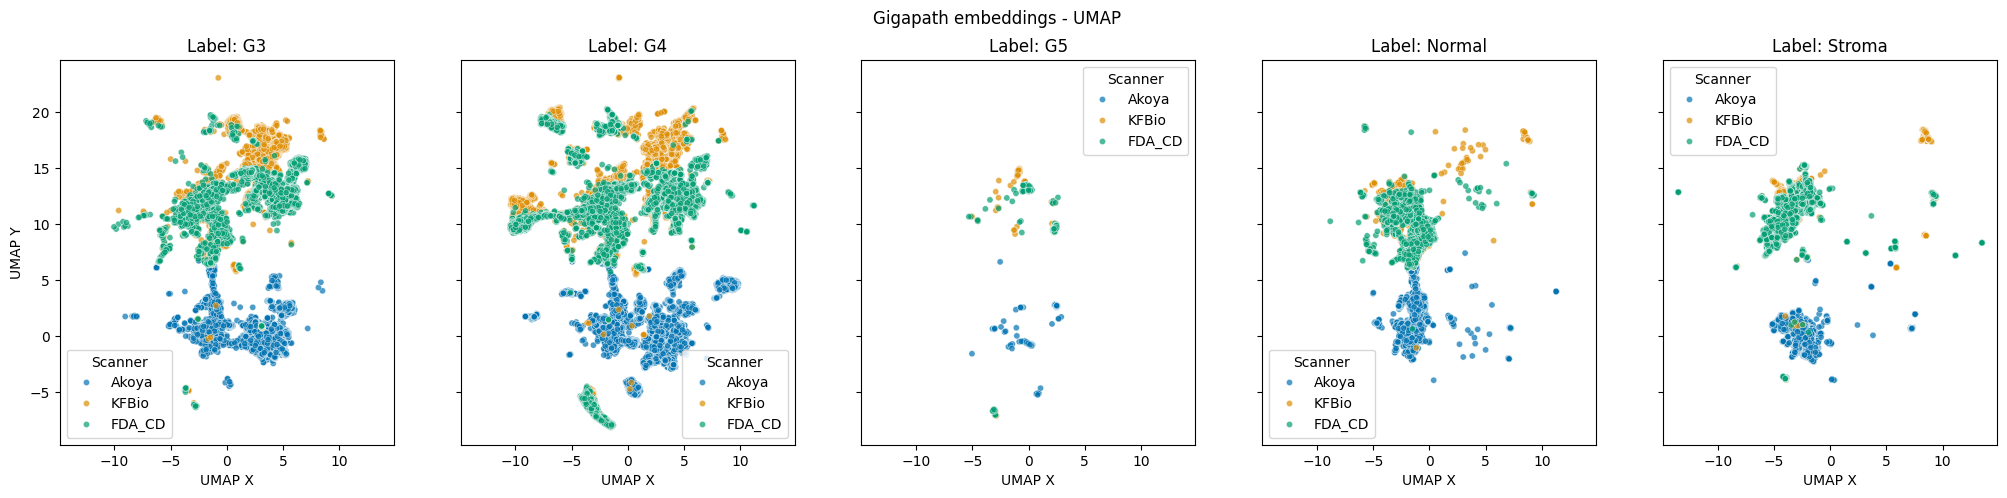

In [15]:
fig, axs = plt.subplots(1, n_labels, figsize=(5 * n_labels, 5), sharex=True, sharey=True)


palette = sns.color_palette("colorblind")
for ax, label in zip(axs, unique_labels):
    data = df_all[df_all["label"] == label]
    sns.scatterplot(
        data=data,
        x="umap_x",
        y="umap_y",
        hue="scanner",
        palette=palette,
        ax=ax,
        s=20,
        alpha=0.7
    )
    ax.set_title(f"Label: {label}")
    ax.set_xlabel("UMAP X")
    ax.set_ylabel("UMAP Y")
    ax.legend(title="Scanner")

#plt.tight_layout()
plt.suptitle('Gigapath embeddings - UMAP')
plt.savefig("/home/leolr-int/nfs/ASTAR_internship/embeddings_gen/images/FDA_CD_labels.png")
plt.show()


/tmp/ipykernel_496433/2642620985.py:14: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/2642620985.py:14: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/2642620985.py:14: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/2642620985.py:14: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/2642620985.py:14: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(


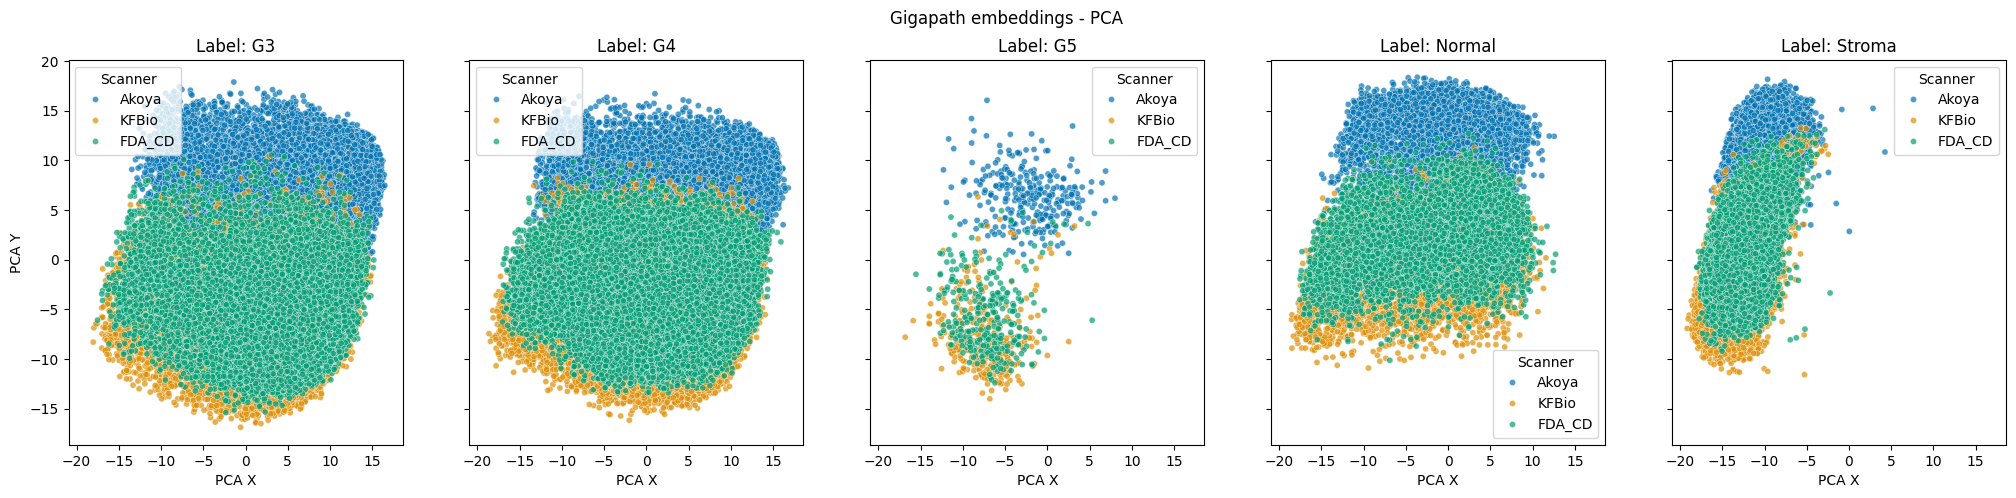

In [16]:
# Test visualisation with PCA
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

df_all["pca_x"] = pca_result[:, 0]
df_all["pca_y"] = pca_result[:, 1]

fig, axs = plt.subplots(1, n_labels, figsize=(5 * n_labels, 5), sharex=True, sharey=True)
for ax, label in zip(axs, unique_labels):
    data = df_all[df_all["label"] == label]
    sns.scatterplot(
        data=data,
        x="pca_x", 
        y="pca_y",  
        hue="scanner",
        ax=ax,
        palette=palette,
        s=20,
        alpha=0.7
    )
    ax.set_title(f"Label: {label}")
    ax.set_xlabel("PCA X") 
    ax.set_ylabel("PCA Y") 
    ax.legend(title="Scanner")

plt.suptitle('Gigapath embeddings - PCA')
#plt.savefig("/home/leolr-int/nfs/ASTAR_internship/embeddings_gen/images/FDA_005_labels.png")
plt.show()

/tmp/ipykernel_496433/873600080.py:7: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/873600080.py:7: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(
/tmp/ipykernel_496433/873600080.py:7: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.scatterplot(


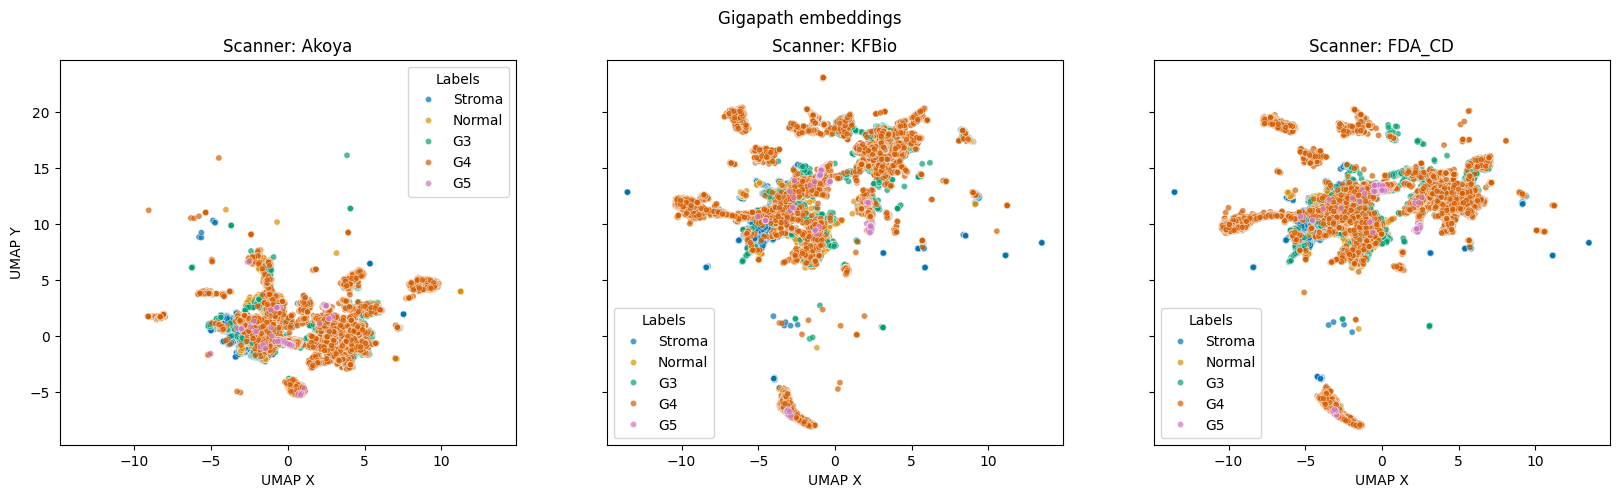

In [21]:
fig, axs = plt.subplots(1, 3, figsize=(5 * 4, 5), sharex=True, sharey=True)



for ax, scanner in zip(axs, scanners):
    data = df_all[df_all["scanner"] == scanner]
    sns.scatterplot(
        data=data,
        x="umap_x",
        y="umap_y",
        hue="label",
        palette=palette,
        ax=ax,
        s=20,
        alpha=0.7
    )
    ax.set_title(f"Scanner: {scanner}")
    ax.set_xlabel("UMAP X")
    ax.set_ylabel("UMAP Y")
    ax.legend(title="Labels")

#plt.tight_layout()
plt.suptitle('Gigapath embeddings')
plt.savefig("/home/leolr-int/nfs/ASTAR_internship/embeddings_gen/images/FDA_CD_scanner.png")
plt.show()

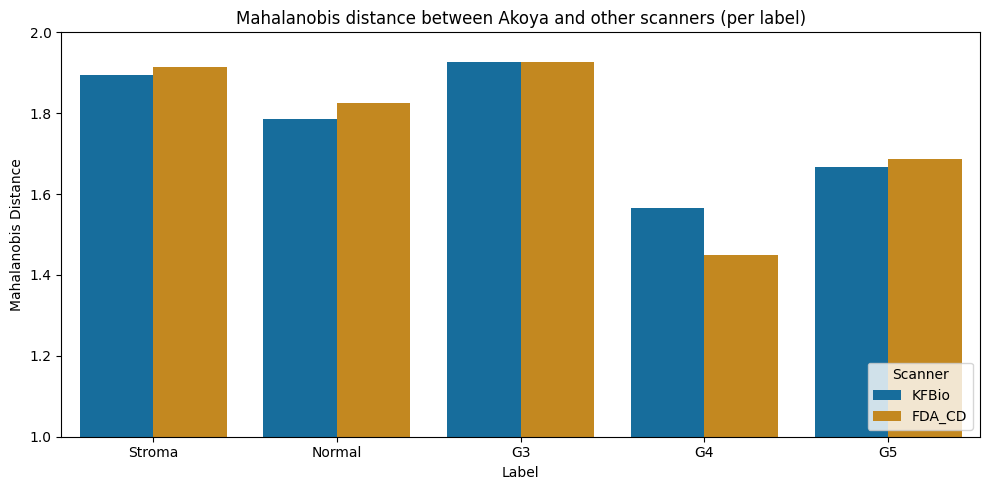

In [22]:
# histogram with Mahalanobis distance to Akoya cluster

from scipy.spatial.distance import mahalanobis
from collections import defaultdict

REFERENCE_SCANNER = "Akoya"
FEATURES = ["umap_x", "umap_y"]


scanner_to_distances = defaultdict(dict)

for label in df_all["label"].unique():
    df_label = df_all[df_all["label"] == label]

    scanners_present = df_label["scanner"].unique()
    if REFERENCE_SCANNER not in scanners_present:
        continue

    for other_scanner in scanners_present:
        if other_scanner == REFERENCE_SCANNER:
            continue

        emb_ref = df_label[df_label["scanner"] == REFERENCE_SCANNER][FEATURES].values
        emb_other = df_label[df_label["scanner"] == other_scanner][FEATURES].values

        cov = np.cov(np.vstack((emb_ref, emb_other)).T)
        cov_inv = np.linalg.pinv(cov)

        # Centroids
        mu_ref = emb_ref.mean(axis=0)
        mu_other = emb_other.mean(axis=0)

        dist = mahalanobis(mu_ref, mu_other, cov_inv)

        scanner_to_distances[other_scanner][label] = dist

df_plot = pd.DataFrame([
    {"label": label, "scanner": scanner, "distance": dist}
    for scanner, dists in scanner_to_distances.items()
    for label, dist in dists.items()
])

# Affichage
plt.figure(figsize=(10, 5))
sns.barplot(data=df_plot, x="label", y="distance", hue="scanner", palette="colorblind")
plt.title("Mahalanobis distance between Akoya and other scanners (per label)")
plt.ylabel("Mahalanobis Distance")
plt.xlabel("Label")
plt.ylim(1,2) 
plt.legend(title="Scanner",loc='lower right')
plt.tight_layout()
plt.show()